---
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.17.3
  kernelspec:
    display_name: .venv
    language: python
    name: python3
title: Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)
---



<a href="https://colab.research.google.com/github/lukaszradlinski/UM25_26_SL_Lista_2/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.

## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from typing import cast

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

![Źródło](https://www.kaggle.com/competitions/titanic)
| Variable | Definition | Key |
| :--- | :--- | :--- |
| survival | Survival | 0 = No, 1 = Yes |
| pclass | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| sex | Sex | |
| Age | Age in years | |
| sibsp | # of siblings / spouses aboard the Titanic | |
| parch | # of parents / children aboard the Titanic | |
| ticket | Ticket number | |
| fare | Passenger fare | |
| cabin | Cabin number | |
| embarked | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

In [2]:
# wczytanie zbioru danych
titanic = pd.read_csv("./titanic.csv")

titanic.shape

(891, 12)

In [3]:
titanic.drop("PassengerId", axis=1).describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
titanic.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Przekształcenie danych

In [5]:
titanic["Sex"] = np.where(titanic["Sex"] == "male", 1, 0)
titanic = titanic.rename(columns={"Sex":"Male"})

embarked_dict = {}
i = 0
for v in titanic["Embarked"].unique():
    embarked_dict[v] = i
    i += 1

titanic["Embarked"] = titanic["Embarked"].map(embarked_dict)
titanic.head(20)

,PassengerId,Survived,Pclass,Name,Male,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,0
5,6,0,3,"Moran, Mr. James",1,NaN,0,0,330877,8.4583,NaN,2
6,7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,E46,0
7,8,0,3,"Palsson, Master. Gosta Leonard",1,2.0,3,1,349909,21.0750,NaN,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.0,0,2,347742,11.1333,NaN,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.0,1,0,237736,30.0708,NaN,1


## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.


### Wiek pasażera

In [6]:
missing_age = titanic["Age"].isna()
random_ages = np.random.choice(titanic["Age"].dropna(), size=missing_age.sum())
titanic.loc[missing_age, "Age"] = random_ages

In [7]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"

### Zaokrętowanie

In [8]:
missing_embarked = titanic["Embarked"].isna()
random_embarked = np.random.choice(titanic["Embarked"].dropna(), size=missing_embarked.sum())
titanic.loc[missing_embarked, "Embarked"] = random_embarked

In [9]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

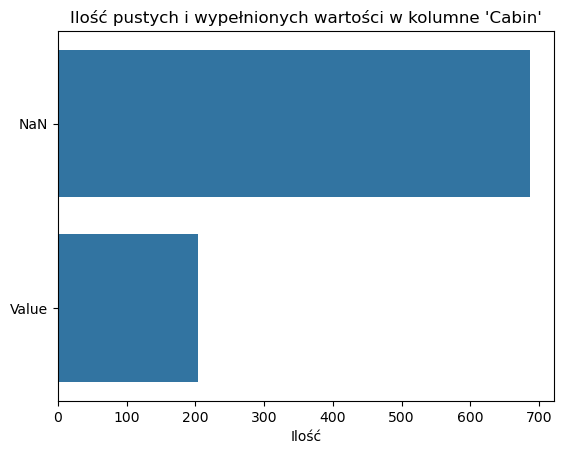

In [10]:
sns.countplot(np.where(titanic["Cabin"].isna(), "NaN", "Value"))
plt.title("Ilość pustych i wypełnionych wartości w kolumne 'Cabin'")
plt.xlabel("Ilość")
plt.show()

In [11]:
titanic = titanic.drop("Cabin", axis=1)

In [12]:
assert not "Cabin" in titanic or titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [13]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

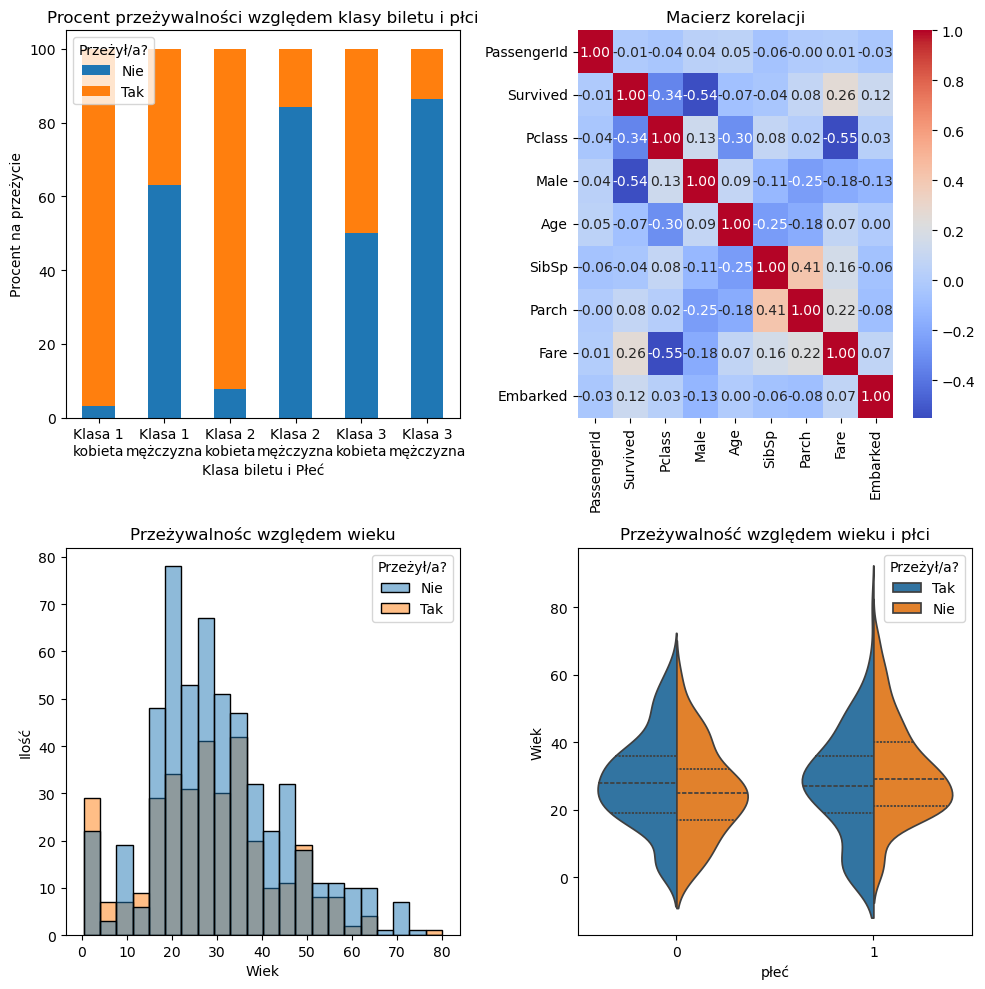

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

titanic["Przeżył/a?"] = titanic["Survived"].map({0: "Nie", 1: "Tak"})

current_ax = axes[0]

cross = pd.crosstab([titanic["Pclass"], titanic["Male"]], titanic["Przeżył/a?"], normalize="index") * 100
cross.plot(
    kind="bar",
    stacked=True,
    ax=current_ax,
    title="Procent przeżywalności względem klasy biletu i płci",
    xlabel="Klasa biletu i Płeć",
    ylabel="Procent na przeżycie"
)
formatted_labels = [f"Klasa {pclass}\n" + ("mężczyzna" if sex == 1 else "kobieta") for pclass, sex in cross.index]
current_ax.set_xticklabels(formatted_labels, rotation=0)

current_ax = axes[1]
titanic_numeric = titanic.select_dtypes(include=["number"])
sns.heatmap(
    titanic_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=current_ax
)
current_ax.set_title("Macierz korelacji")

current_ax = axes[2]
sns.histplot(data=titanic, x="Age", hue="Przeżył/a?", ax=current_ax)
current_ax.set_title("Przeżywalnośc względem wieku")
current_ax.set_xlabel("Wiek")
current_ax.set_ylabel("Ilość")

current_ax = axes[3]
sns.violinplot(data=titanic, x="Male", y="Age", hue="Przeżył/a?", split=True, inner="quartile", ax=current_ax)
current_ax.set_title("Przeżywalność względem wieku i płci")
current_ax.set_xlabel("płeć")
current_ax.set_ylabel("Wiek")

titanic.drop("Przeżył/a?", axis=1)

plt.tight_layout()
plt.show()

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

In [15]:
survived_mask = titanic["Survived"] == 1

total_people = len(titanic["PassengerId"])
total_survived = len(titanic[survived_mask])

print(f"Ogólna przeżywalność: {total_survived / total_people:.2f}%")

first_class_mask = titanic["Pclass"] == 1

total_first_class = len(titanic[first_class_mask])
survived_first_class = len(titanic[first_class_mask & survived_mask])

print(f"Przeżywalność wśród podróżujących pierwszą klasą: {survived_first_class / total_first_class:.2f}%")

women_mask = titanic["Male"] == 0

total_women = len(titanic[women_mask])
survived_women = len(titanic[women_mask & survived_mask])

print(f"Przeżywalnośc wśród kobiet: {survived_women / total_women:.2f}%")

total_women_first_class = len(titanic[women_mask & first_class_mask])
total_women_first_class_survived = len(titanic[women_mask & first_class_mask & survived_mask])

print(f"Przeżywalność wśród kobiet podróżujący pierwszą klasą: {total_women_first_class_survived / total_women_first_class:.2f}%")

Ogólna przeżywalność: 0.38%
Przeżywalność wśród podróżujących pierwszą klasą: 0.63%
Przeżywalnośc wśród kobiet: 0.74%
Przeżywalność wśród kobiet podróżujący pierwszą klasą: 0.97%


# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

![Źródło](./https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-1921-2020-160k-tracks)
valence - The positiveness of the track in range 0 to 1
year - The year of release
acousticness - How acoustic a track is in range 0 to 1
artists - artists who created the track
danceability - how danceable a song is in range 0 to 1
duration_ms - duration of songs in mswhether it contains explicit content or not
energy - how energized a song is in range 0 to 1
explicit - whether it contains explicit content or not
id - id of track
instrumentalness - The absence of vocal sounds in track in range 0 to 1 
key - major note of track
liveness - The presence of audience in track in range 0 to 1
loudness - How loud a song is in db
mode - The modality of track, 0 if minor and 1 if major
name - name of track
popularity - popularity of track in range 0 to 100
release_date - date of release
speechiness - The presence of spoken words in track in range 0 to 1
tempo - The overall tempo of track in BPM

In [16]:
spotify = pd.read_csv("./spotify.csv")

spotify.shape

(170653, 19)

In [17]:
spotify.head(20)

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.9820,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.2110,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.6650,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.7320,['Dennis Day'],0.819,180533,0.3410,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.1600,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.9610,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.1660,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.1010,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.9670,['Frank Parker'],0.275,210000,0.3090,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.3810,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.9570,['Phil Regan'],0.418,166693,0.1930,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.2290,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665
5,0.1960,1921,0.5790,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.697,395076,0.3460,0,4pyw9DVHGStUre4J6hPngr,0.168000,2,0.1300,-12.506,1,Gati Mardika,6,1921,0.0700,119.824
6,0.4060,1921,0.9960,['John McCormack'],0.518,159507,0.2030,0,5uNZnElqOS3W4fRmRYPk4T,0.000000,0,0.1150,-10.589,1,The Wearing of the Green,4,1921,0.0615,66.221
7,0.0731,1921,0.9930,['Sergei Rachmaninoff'],0.389,218773,0.0880,0,02GDntOXexBFUvSgaXLPkd,0.527000,1,0.3630,-21.091,0,"Morceaux de fantaisie, Op. 3: No. 2, Prélude i...",2,1921,0.0456,92.867
8,0.7210,1921,0.9960,['Ignacio Corsini'],0.485,161520,0.1300,0,05xDjWH9ub67nJJk82yfGf,0.151000,5,0.1040,-21.508,0,La Mañanita - Remasterizado,0,1921-03-20,0.0483,64.678
9,0.7710,1921,0.9820,['Fortugé'],0.684,196560,0.2570,0,08zfJvRLp7pjAb94MA9JmF,0.000000,8,0.5040,-16.415,1,Il Etait Syndiqué,0,1921,0.3990,109.378


## Przekształcenia i filtracja danych

In [18]:
spotify["mode_str"] = np.where(spotify["mode"] == 1, "Major", "Minor")

## Wizualizacje

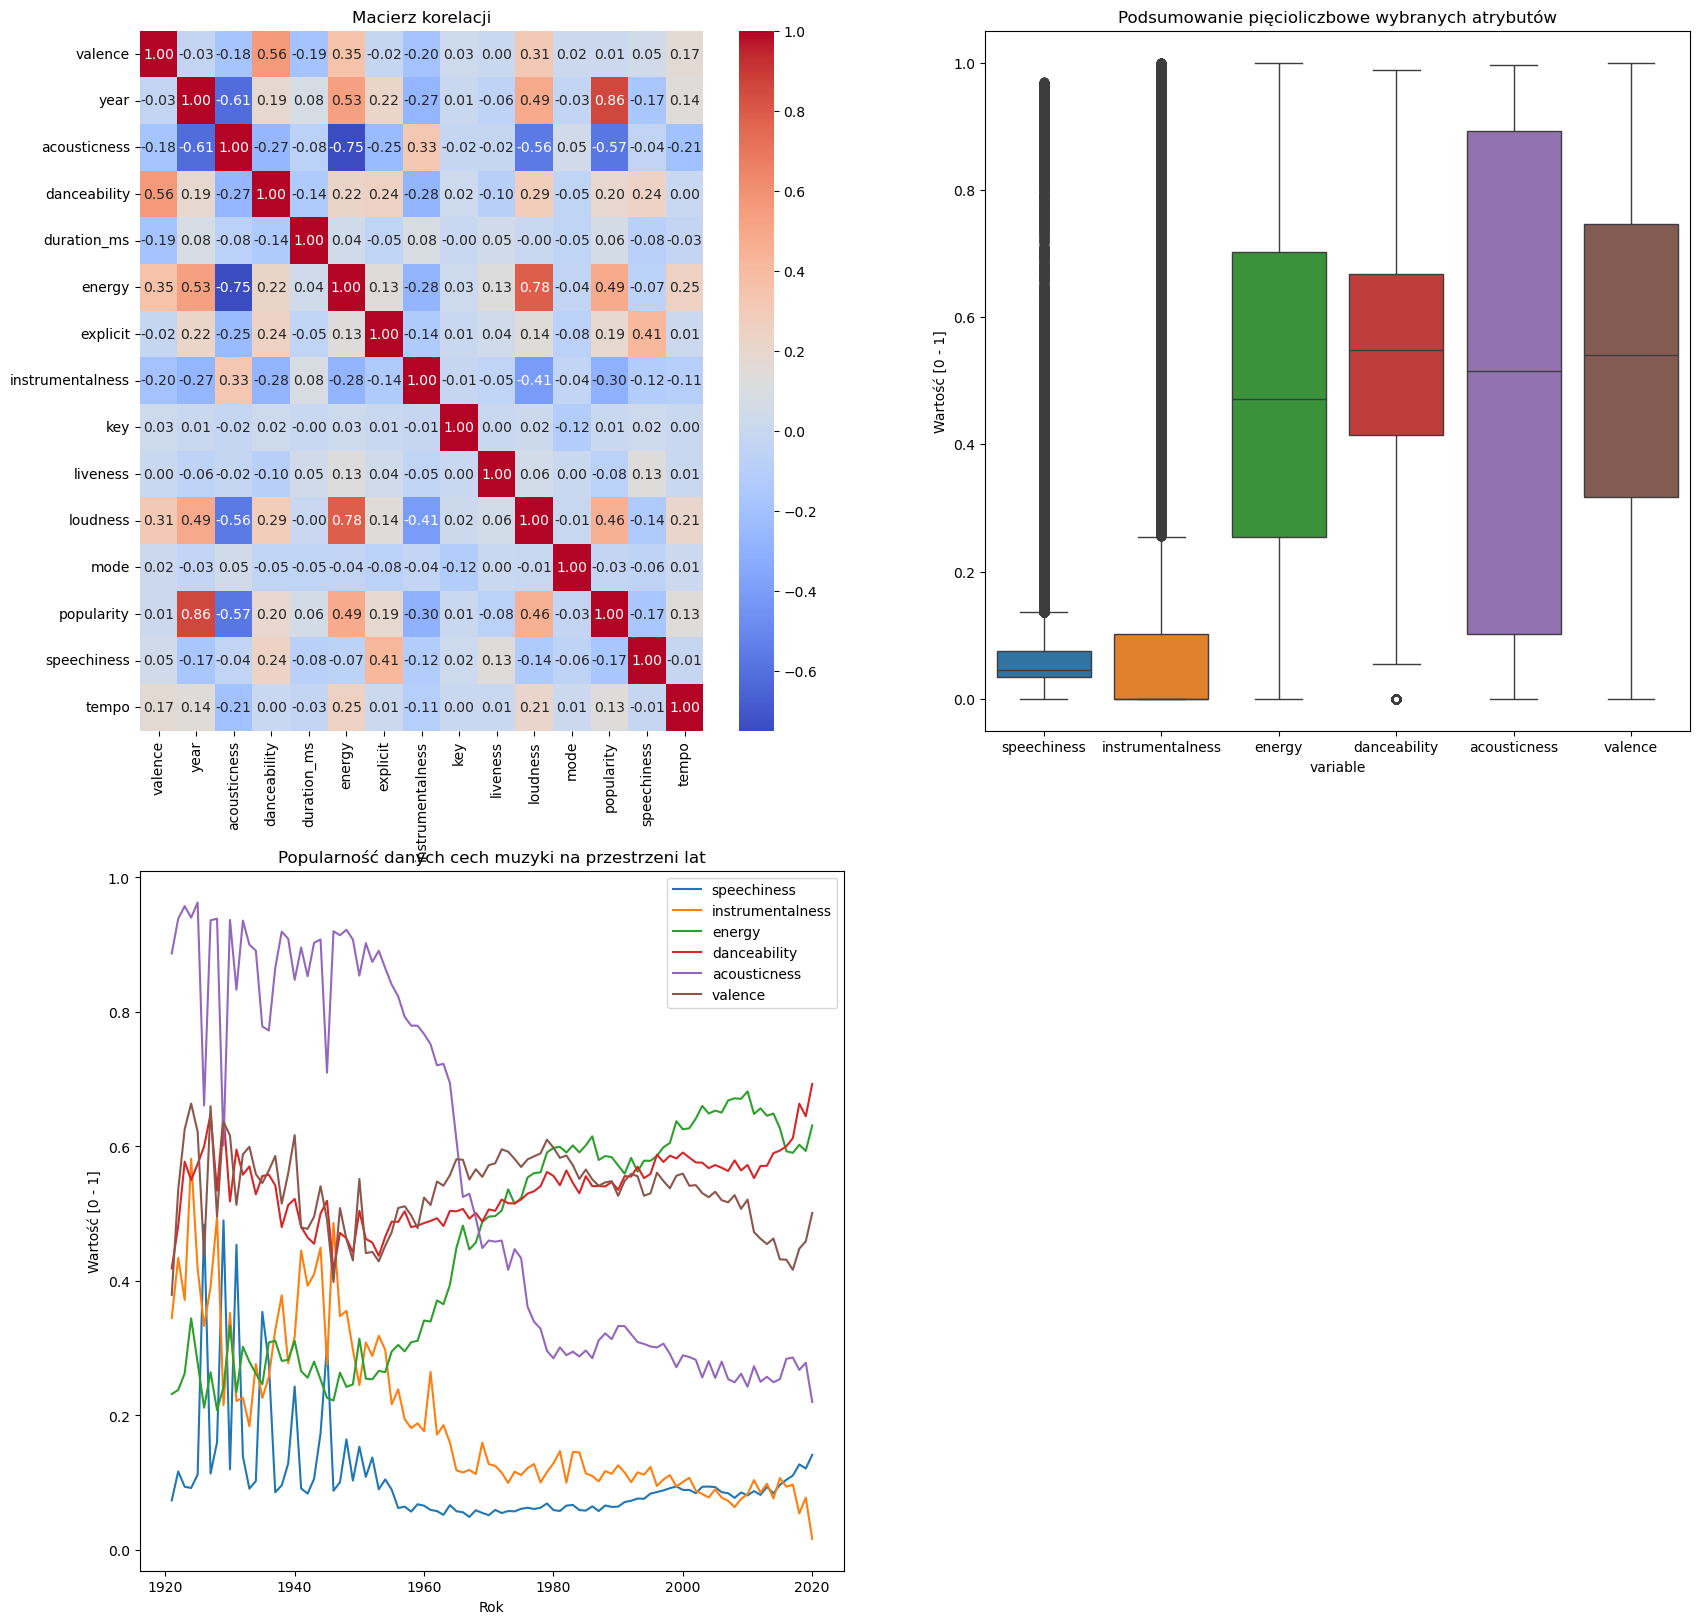

In [19]:
music_features = ["speechiness", "instrumentalness", "energy", "danceability", "acousticness", "valence"]

fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()
fig.delaxes(axes[-1])

current_ax = axes[0]
spotify_numeric = spotify.select_dtypes(include=["number"])
sns.heatmap(
    spotify_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=current_ax
)
current_ax.set_title("Macierz korelacji")

current_ax = axes[1]
sns.boxplot(data=pd.melt(spotify[music_features]), x="variable", y="value", hue="variable", ax = current_ax)
current_ax.set_title("Podsumowanie pięcioliczbowe wybranych atrybutów")
current_ax.set_ylabel("Wartość [0 - 1]")

current_ax = axes[2]
spotify.groupby('year')[music_features].mean() \
    .plot(
        ax=current_ax,
        title="Popularność danych cech muzyki na przestrzeni lat",
        ylabel="Wartość [0 - 1]",
        xlabel="Rok"
    )

plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [20]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [21]:
spotify["key_str"] = spotify["key"].map(key_map)
spotify["emotion"] = spotify[["key_str", "mode_str"]] \
                    .apply(lambda sp: \
                       cast(pd.Series, emotion_map.get((sp["key_str"], sp["mode_str"]))),
                       axis=1
                    )

spotify[["key_str", "mode_str", "emotion"]].head(10)

,key_str,mode_str,emotion
0,A#,Major,Magnificent
1,G,Major,Rustic
2,D#,Major,Cruel
3,F,Major,Passionate
4,D#,Major,Cruel
5,D,Major,Triumphant
6,C,Major,Happy
7,C#,Minor,Melancholic
8,F,Minor,Tragic
9,G#,Major,Rich


## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji


### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [22]:
from itertools import combinations

corr_matrix = spotify.select_dtypes(include=["number"]).corr().abs()
cols_pairs = combinations(spotify.select_dtypes(include=["number"]).keys(), 2)
high_corr = [cols for cols in cols_pairs if corr_matrix.loc[*cols] > 0.75]

print(f"Kolumny z korelacją >0.75: {high_corr}")

to_be_removed = [col[0] for col in high_corr] 
spotify_filtered = spotify.drop(columns=to_be_removed)

Kolumny z korelacją >0.75: [('year', 'popularity'), ('energy', 'loudness')]


### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [24]:
feats = spotify.select_dtypes(include="number").drop(columns=["popularity"])

best_features = []
best_overall_acc = 0.0

while True:
    best_new_feature = None
    best_step_acc = 0.0
    
    for feature in feats:
        if feature not in best_features:
            current_test_features = best_features + [feature]
            
            acc = classify(spotify, current_test_features)
            
            if acc > best_step_acc:
                best_step_acc = acc
                best_new_feature = feature
                
    if best_step_acc > best_overall_acc:
        best_overall_acc = best_step_acc
        best_features.append(best_new_feature)
    else:
        break

print(best_features, best_overall_acc)

Features  : ['valence']
Test Acc  : 0.5396
Features  : ['year']
Test Acc  : 0.7719


Features  : ['acousticness']
Test Acc  : 0.6393


Features  : ['danceability']
Test Acc  : 0.5294


Features  : ['duration_ms']
Test Acc  : 0.5948


Features  : ['energy']
Test Acc  : 0.6230
Features  : ['explicit']
Test Acc  : 0.5450


...

Features  : ['year', 'explicit', 'instrumentalness', 'speechiness', 'key']
Test Acc  : 0.7821


Features  : ['year', 'explicit', 'instrumentalness', 'speechiness', 'liveness']
Test Acc  : 0.7731


Features  : ['year', 'explicit', 'instrumentalness', 'speechiness', 'loudness']
Test Acc  : 0.7797


Features  : ['year', 'explicit', 'instrumentalness', 'speechiness', 'mode']
Test Acc  : 0.7725


Features  : ['year', 'explicit', 'instrumentalness', 'speechiness', 'tempo']
Test Acc  : 0.7791
['year', 'explicit', 'instrumentalness', 'speechiness'] 0.7833133253301321


### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [25]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

In [26]:
# przykładowe funkcje

def dataframe_xy(df, feat_list, target):
    X = df[feat_list].values
    y = df[target].values
    return X, y

# normalize to [0,1] range
def normalize(X):
    scaler = MinMaxScaler()
    return scaler.fit_transform(X)

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)

# remove outliers
def remove_outliers(X, y):
    q1 = np.percentile(X, 25, axis=0)
    q3 = np.percentile(X, 75, axis=0)

    iqr = q3 - q1
    iqr_mul = iqr * 1.5

    outlier_filter = (X >= q1 - iqr_mul) & (X <= q3 + iqr_mul)

    mask = outlier_filter.all(axis=1)

    X_cleaned = X[mask]
    y_cleaned = y[mask]

    return X_cleaned, y_cleaned

In [27]:
limit = 5000
spotify["popularity_bracket"] = pd.cut(
    spotify["popularity"],
    bins=[0, 33, 66, 100],
    labels=["low", "mid", "high"],
    include_lowest=True
)

X, y = dataframe_xy(spotify, best_features, "popularity_bracket")
y = LabelEncoder().fit_transform(y)
X, y = remove_outliers(X, y)
X, y = X[:limit], y[:limit]

X_std = standarize(X)
X_norm = normalize(X)

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=100)

X_std_pca = pca.fit_transform(X_std)
X_norm_pca = pca.fit_transform(X_norm)

X_std_tsne = tsne.fit_transform(X_std)
X_norm_tsne = tsne.fit_transform(X_norm)

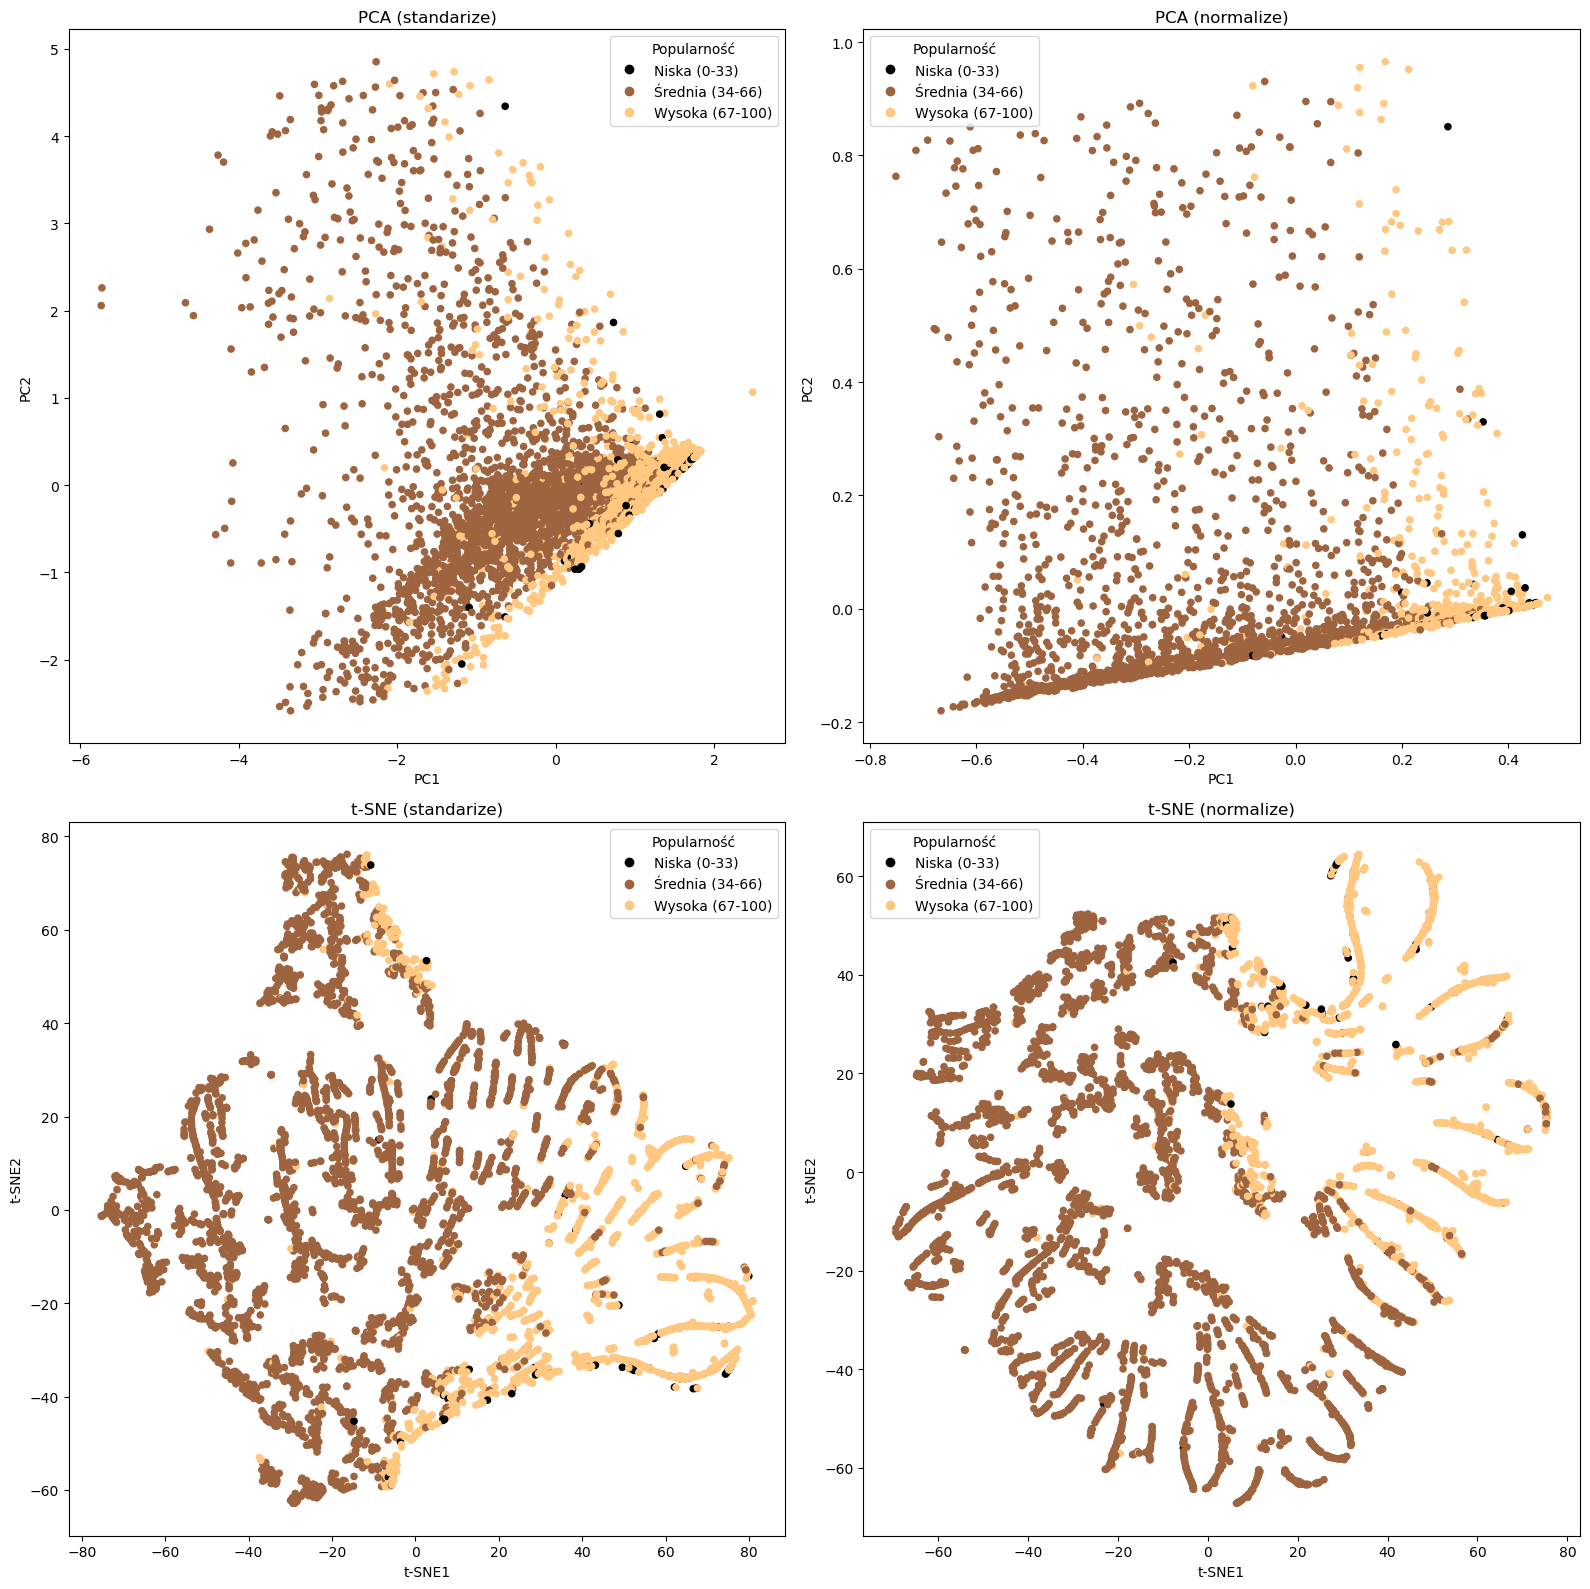

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

def draw_plot(df, x, y, title, ax):
    plot = df.plot(
        kind="scatter",
        x=x,
        y=y,
        c="popularity",
        title=title,
        colormap="copper",
        colorbar=False,
        ax=ax,
    )
    labels = ["Niska (0-33)", "Średnia (34-66)", "Wysoka (67-100)"]
    legend_elements = plot.collections[0].legend_elements()[0]
    ax.legend(legend_elements, labels, title="Popularność")

df_std_pca = pd.DataFrame(X_std_pca, columns=["PC1", "PC2"])
df_std_pca["popularity"] = y
draw_plot(df_std_pca, "PC1", "PC2", "PCA (standarize)", axes[0])

df_norm_pca = pd.DataFrame(X_norm_pca, columns=["PC1", "PC2"])
df_norm_pca["popularity"] = y
draw_plot(df_norm_pca, "PC1", "PC2", "PCA (normalize)", axes[1])

df_std_tsne = pd.DataFrame(X_std_tsne, columns=["t-SNE1", "t-SNE2"])
df_std_tsne["popularity"] = y
draw_plot(df_std_tsne, "t-SNE1", "t-SNE2", "t-SNE (standarize)", axes[2])

df_norm_tsne = pd.DataFrame(X_norm_tsne, columns=["t-SNE1", "t-SNE2"])
df_norm_tsne["popularity"] = y
draw_plot(df_norm_tsne, "t-SNE1", "t-SNE2", "t-SNE (normalize)", axes[3])

plt.tight_layout()
plt.show()